# Modeling — Purchase Propensity

In this notebook, I'll:

- choose a main model after comparing several with default parameters
- tune hyperparameters on a single fold, evaluate on a held-out validation users
- evaluate per-category performance and feature importance
- evaluate isotonic calibration using a calib/eval split of the val set
- run a negative sampling experiment to show that training scaffold choice matters
- produce final test predictions

The output is a propensity score for every (user, category)-pair. A marketing or personalization team can use this for a ranked list of users per category and target the top n with a campaign, push notification or recommendation slot. Scores are closely aligned with observed purchase rates (see section 8 on calibration), enabling expected-value calculations, for instance, expected revenue per contact = propensity x average order value per category. Checking the key assumption that high-propensity users have higher expected return per contact would involve uplift modeling, see limitations note at the end.

## Sections
1. Setup
2. Load Features
3. Validation Set
4. Model Comparison
5. LightGBM Hyperparameter Search
6. LightGBM Full CV
7. Evaluation
8. Calibration
9. Negative Sampling Experiment
10. Final Model & Test Predictions
11. Conclusion

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time, copy
from pathlib import Path

from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, log_loss, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
import lightgbm as lgb
import xgboost as xgb

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

FEATURES_DIR = Path('../data')
SEED         = 42
N_FOLDS      = 5
KEPT_CATS    = ['electronics', 'appliances', 'computers', 'furniture',
                'apparel', 'auto', 'construction', 'kids']

## 2. Load Features

In [2]:
train = pd.read_parquet(FEATURES_DIR / 'train_features.parquet')
test  = pd.read_parquet(FEATURES_DIR / 'test_features.parquet')

print(f'Train: {train.shape[0]:,} | positive rate: {train["label"].mean():.2%}')
print(f'Test:    {test.shape[0]:,} | positive rate: {test["label"].mean():.2%}')

Train: 1,395,712 | positive rate: 3.22%
Test:    348,928 | positive rate: 3.24%


## 3. Validation Set

I'll hold out 20% of training users as a labeled validation set before any modelling. These users are absent from every training fold, meant to measure generalization to completely unseen users. The test set is never touched until section 10.

The positive rate on val set will serve as an anchor; a well-calibrated model's mean predicted probability should match the positive rate on unseen data.

In [3]:
all_train_users = np.sort(train['user_id'].unique())
rng             = np.random.default_rng(SEED)
val_user_ids    = set(rng.choice(all_train_users, size=int(len(all_train_users) * 0.2), replace=False))

train_pool = train[~train['user_id'].isin(val_user_ids)].copy()
val_df     = train[ train['user_id'].isin(val_user_ids)].copy()

val_pos_rate = val_df['label'].mean()

print(f'{"Split":<15} {"users":>8}  {"rows":>10}  {"pos rate":>10}')
print('-' * 52)
print(f'{"train_pool":<15} {train_pool["user_id"].nunique():>8,}  {len(train_pool):>10,}  {train_pool["label"].mean():>10.2%}')
print(f'{"val_df":<15} {val_df["user_id"].nunique():>8,}  {len(val_df):>10,}  {val_df["label"].mean():>10.2%}')

Split              users        rows    pos rate
----------------------------------------------------
train_pool       139,572   1,116,576       3.23%
val_df            34,892     279,136       3.18%


## 4. Model Comparison

I'll compare several models with default hyperparameters to see which ones are worth pursuing. I'll exclude random forest here as gradient boosting options consistently perform better than a bagging ensemble on tabular data, and at this dataset's size the 5-fold cross-validation has a long runtime.

Two evaluation views:
1. OOF: 5-fold GroupKFold on `train_pool`, grouped by user so that all rows belonging to a user stay in the same fold, preventing leakage across the scaffold
2. On val set: Users held out entirely from training, measuring generalization to unseen users

We would expect a small gap between OOF and val, but a large gap signals overfitting to the train set that OOF alone would miss.

Comparing val mean prob vs val positive rate is also a quick first calibration check.

In [4]:
cat_cols = ['category_l1']
num_cols = [
    'views_30d', 'carts_30d', 'purchases_30d',
    'views_14d', 'carts_14d', 'purchases_14d',
    'views_7d', 'carts_7d', 'purchases_7d',
    'days_since_view', 'days_since_cart', 'days_since_purchase',
    'total_views_30d', 'total_carts_30d', 'total_purchases_30d',
    'active_days_30d', 'category_breadth_30d', 'session_count_30d',
    'cat_purchase_rate', 'cart_view_ratio_30d', 'cart_view_ratio_7d',
    'brand_count_30d',
    'avg_price_viewed_30d', 'avg_price_carted_30d',
]
feature_cols = num_cols + cat_cols

# LR: impute nulls with -1, scale numerics, OHE categoricals
lr_prep = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value=-1)),
        ('scl', StandardScaler()),
    ]), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

# Tree models (XGBoost, HistGBM): impute + OHE
tree_prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='constant', fill_value=-1), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

# train_pool arrays
X_pool_sk  = train_pool[feature_cols].copy()
X_pool_lgb = train_pool[feature_cols].copy()
for col in cat_cols:
    X_pool_lgb[col] = X_pool_lgb[col].astype('category')

y_pool      = train_pool['label']
groups_pool = train_pool['user_id']

# val arrays
X_val_sk  = val_df[feature_cols].copy()
X_val_lgb = val_df[feature_cols].copy()
for col in cat_cols:
    X_val_lgb[col] = X_val_lgb[col].astype('category')

y_val = val_df['label'].values
gkf   = GroupKFold(n_splits=N_FOLDS)

print(f'Features: {len(feature_cols)} ({len(num_cols)} numeric, {len(cat_cols)} categorical)')
print(f'train_pool: {len(X_pool_sk):,} rows | val_df: {len(X_val_sk):,} rows')

Features: 25 (24 numeric, 1 categorical)
train_pool: 1,116,576 rows | val_df: 279,136 rows


In [5]:
# Naive baseline: category purchase rate
cat_rates        = train_pool.groupby('category_l1')['label'].mean()
naive_pool_preds = train_pool['category_l1'].map(cat_rates).values
naive_val_preds  = val_df['category_l1'].map(cat_rates).fillna(cat_rates.mean()).values

results = {}
results['Naive Baseline'] = {
    'oof_auc':       roc_auc_score(y_pool, naive_pool_preds),
    'oof_logloss':   log_loss(y_pool, naive_pool_preds),
    'val_auc':       roc_auc_score(y_val,  naive_val_preds),
    'val_logloss':   log_loss(y_val,  naive_val_preds),
    'val_mean_prob': float(naive_val_preds.mean()),
    'time_s':        0.0,
}
r = results['Naive Baseline']
print(f'Naive Baseline')
print(f'OOF - AUC: {r["oof_auc"]:.4f}  LogLoss: {r["oof_logloss"]:.4f}')
print(f'Val - AUC: {r["val_auc"]:.4f}  LogLoss: {r["val_logloss"]:.4f}  MeanProb: {r["val_mean_prob"]:.4f}  (true: {val_pos_rate:.4f})')

Naive Baseline
OOF - AUC: 0.8699  LogLoss: 0.1061
Val - AUC: 0.8705  LogLoss: 0.1048  MeanProb: 0.0323  (true: 0.0318)


In [6]:
sklearn_models = {
    'Logistic Regression': Pipeline([
        ('prep', lr_prep),
        ('clf', LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)),
    ]),
    'HistGradientBoosting': Pipeline([
        ('prep', tree_prep),
        ('clf', HistGradientBoostingClassifier(
            max_iter=300, random_state=SEED,
        )),
    ]),
    'XGBoost': Pipeline([
        ('prep', tree_prep),
        ('clf', xgb.XGBClassifier(
            n_estimators=500, learning_rate=0.1, n_jobs=-1, random_state=SEED,
            eval_metric='logloss', early_stopping_rounds=50, verbosity=0,
        )),
    ]),
}

for name, pipeline in sklearn_models.items():
    print(f'\n{name}')
    print('-' * 50)
    oof = np.zeros(len(X_pool_sk))
    xgb_best_iters = []
    t0 = time.time()

    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_pool_sk, y_pool, groups_pool)):
        if name == 'XGBoost':
            prep = clone(pipeline.named_steps['prep'])
            X_tr_t = prep.fit_transform(X_pool_sk.iloc[tr_idx])
            X_vl_t = prep.transform(X_pool_sk.iloc[val_idx])
            clf = clone(pipeline.named_steps['clf'])
            clf.fit(X_tr_t, y_pool.iloc[tr_idx],
                    eval_set=[(X_vl_t, y_pool.iloc[val_idx])], verbose=False)
            oof[val_idx] = clf.predict_proba(X_vl_t)[:, 1]
            xgb_best_iters.append(clf.best_iteration)
        else:
            p = clone(pipeline)
            p.fit(X_pool_sk.iloc[tr_idx], y_pool.iloc[tr_idx])
            oof[val_idx] = p.predict_proba(X_pool_sk.iloc[val_idx])[:, 1]

        print(f'Fold {fold}: AUC = {roc_auc_score(y_pool.iloc[val_idx], oof[val_idx]):.4f}')

    # Retrain on full train_pool for val predictions
    if name == 'XGBoost':
        mean_bi = int(np.mean(xgb_best_iters))
        prep = clone(pipeline.named_steps['prep'])
        X_pool_t = prep.fit_transform(X_pool_sk)
        X_val_t = prep.transform(X_val_sk)
        final = xgb.XGBClassifier(n_estimators=mean_bi, learning_rate=0.1,
                                n_jobs=-1, random_state=SEED, verbosity=0)
        final.fit(X_pool_t, y_pool)
        val_preds = final.predict_proba(X_val_t)[:, 1]
    else:
        final = clone(pipeline)
        final.fit(X_pool_sk, y_pool)
        val_preds = final.predict_proba(X_val_sk)[:, 1]

    elapsed = time.time() - t0
    results[name] = {
        'oof_auc':       roc_auc_score(y_pool, oof),
        'oof_logloss':   log_loss(y_pool, oof),
        'val_auc':       roc_auc_score(y_val, val_preds),
        'val_logloss':   log_loss(y_val, val_preds),
        'val_mean_prob': float(val_preds.mean()),
        'time_s':        elapsed,
    }
    r = results[name]
    print(f'OOF: AUC {r["oof_auc"]:.4f}  LL {r["oof_logloss"]:.4f}  |  '
          f'Val: AUC {r["val_auc"]:.4f}  LL {r["val_logloss"]:.4f}  '
          f'MeanProb {r["val_mean_prob"]:.4f}  |  {elapsed:.0f}s')


Logistic Regression
--------------------------------------------------
Fold 0: AUC = 0.9102
Fold 1: AUC = 0.9076
Fold 2: AUC = 0.9075
Fold 3: AUC = 0.9093
Fold 4: AUC = 0.9084
OOF: AUC 0.9086  LL 0.0892  |  Val: AUC 0.9095  LL 0.0877  MeanProb 0.0323  |  43s

HistGradientBoosting
--------------------------------------------------
Fold 0: AUC = 0.9461
Fold 1: AUC = 0.9459
Fold 2: AUC = 0.9460
Fold 3: AUC = 0.9449
Fold 4: AUC = 0.9444
OOF: AUC 0.9453  LL 0.0740  |  Val: AUC 0.9473  LL 0.0725  MeanProb 0.0319  |  54s

XGBoost
--------------------------------------------------
Fold 0: AUC = 0.9463
Fold 1: AUC = 0.9459
Fold 2: AUC = 0.9461
Fold 3: AUC = 0.9450
Fold 4: AUC = 0.9446
OOF: AUC 0.9455  LL 0.0739  |  Val: AUC 0.9473  LL 0.0724  MeanProb 0.0319  |  45s


In [7]:
# LightGBM - default params + native categorical + early stopping
lgb_oof_cmp = np.zeros(len(X_pool_lgb))
lgb_bi_cmp  = []
t0          = time.time()

print('LightGBM (default params)')
print('-' * 50)

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_pool_lgb, y_pool, groups_pool)):
    m = lgb.LGBMClassifier(n_estimators=1000, random_state=SEED, verbose=-1, n_jobs=-1)
    m.fit(
        X_pool_lgb.iloc[tr_idx], y_pool.iloc[tr_idx],
        eval_set=[(X_pool_lgb.iloc[val_idx], y_pool.iloc[val_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    lgb_oof_cmp[val_idx] = m.predict_proba(X_pool_lgb.iloc[val_idx])[:, 1]
    lgb_bi_cmp.append(m.best_iteration_)
    print(f'Fold {fold}: AUC = {roc_auc_score(y_pool.iloc[val_idx], lgb_oof_cmp[val_idx]):.4f}'
          f'(best_iter={m.best_iteration_})')

_mean_iter = int(np.round(np.mean(lgb_bi_cmp)))
_final     = lgb.LGBMClassifier(n_estimators=_mean_iter, random_state=SEED, verbose=-1, n_jobs=-1)
_final.fit(X_pool_lgb, y_pool)
val_preds_lgb_cmp = _final.predict_proba(X_val_lgb)[:, 1]

elapsed = time.time() - t0
results['LightGBM'] = {
    'oof_auc':       roc_auc_score(y_pool, lgb_oof_cmp),
    'oof_logloss':   log_loss(y_pool, lgb_oof_cmp),
    'val_auc':       roc_auc_score(y_val, val_preds_lgb_cmp),
    'val_logloss':   log_loss(y_val, val_preds_lgb_cmp),
    'val_mean_prob': float(val_preds_lgb_cmp.mean()),
    'time_s':        elapsed,
}
r = results['LightGBM']
print(f'\nOOF: AUC {r["oof_auc"]:.4f}  LL {r["oof_logloss"]:.4f}  |  '
      f'Val: AUC {r["val_auc"]:.4f}  LL {r["val_logloss"]:.4f}  '
      f'MeanProb {r["val_mean_prob"]:.4f}  |  {elapsed:.0f}s')

LightGBM (default params)
--------------------------------------------------
Fold 0: AUC = 0.9464(best_iter=96)
Fold 1: AUC = 0.9459(best_iter=78)
Fold 2: AUC = 0.9461(best_iter=77)
Fold 3: AUC = 0.9452(best_iter=60)
Fold 4: AUC = 0.9445(best_iter=109)

OOF: AUC 0.9456  LL 0.0739  |  Val: AUC 0.9472  LL 0.0725  MeanProb 0.0320  |  25s


Val positive rate (ground truth): 0.0318

               Model  OOF AUC  OOF LogLoss  Val AUC  Val LogLoss  Val MeanProb  Time (s)
             XGBoost   0.9455       0.0739   0.9473       0.0724        0.0319   44.6640
HistGradientBoosting   0.9453       0.0740   0.9473       0.0725        0.0319   53.7705
            LightGBM   0.9456       0.0739   0.9472       0.0725        0.0320   25.0069
 Logistic Regression   0.9086       0.0892   0.9095       0.0877        0.0323   43.0938
      Naive Baseline   0.8699       0.1061   0.8705       0.1048        0.0323    0.0000


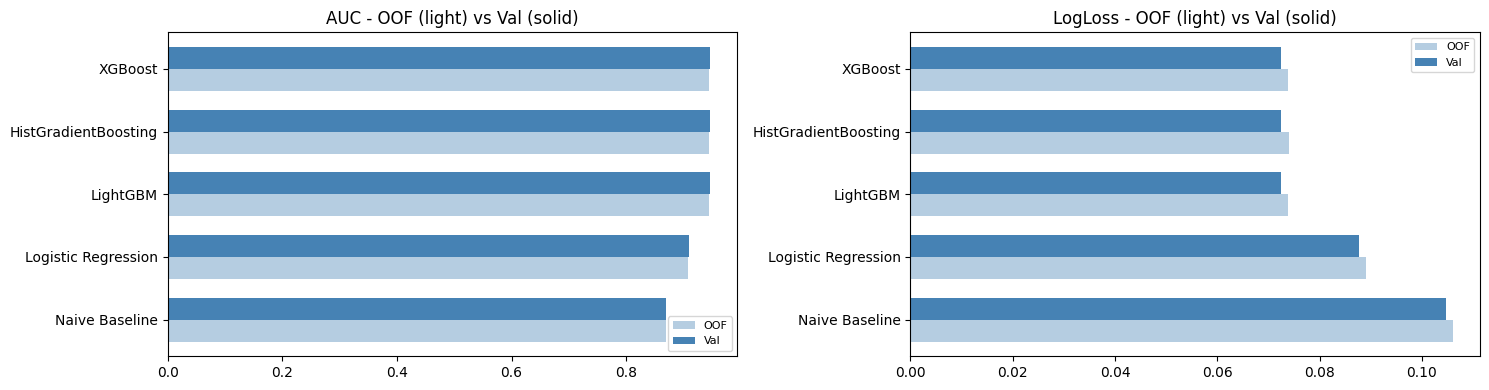

In [8]:
comparison = (
    pd.DataFrame([
        {'Model': name, 'OOF AUC': v['oof_auc'], 'OOF LogLoss': v['oof_logloss'],
         'Val AUC': v['val_auc'], 'Val LogLoss': v['val_logloss'],
         'Val MeanProb': v['val_mean_prob'], 'Time (s)': v['time_s']}
        for name, v in results.items()
    ])
    .sort_values('Val AUC', ascending=False)
    .reset_index(drop=True)
)

print(f'Val positive rate (ground truth): {val_pos_rate:.4f}\n')
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, max(4, len(comparison) * 0.6)))
plot_df = comparison.sort_values('Val AUC', ascending=True)
x, w = np.arange(len(plot_df)), 0.35

for ax, metric, title in [
    (axes[0], ('OOF AUC',     'Val AUC'),     'AUC - OOF (light) vs Val (solid)'),
    (axes[1], ('OOF LogLoss', 'Val LogLoss'), 'LogLoss - OOF (light) vs Val (solid)'),
]:
    ax.barh(x - w/2, plot_df[metric[0]], w, alpha=0.4, color='steelblue', label='OOF')
    ax.barh(x + w/2, plot_df[metric[1]], w, alpha=1.0, color='steelblue', label='Val')
    ax.set_yticks(x)
    ax.set_yticklabels(plot_df['Model'])
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

GBDT family performance seems consistent across models, I'll choose lightgbm as the main model for its speed. I'll keep logistic regression as the baseline as its linear boundary shows what user-level signal adds beyond category base rates.

## 5. LightGBM Hyperparameter Search

Here I'll do a random search over 20 parameter combinations using fold 0 only. Since fold 0 is the tuning fold, I'll exclude it from the OOF metrics in section 6.

Parameters searched: `num_leaves`, `min_child_samples`, `learning_rate`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`.

In [9]:
rng_hp  = np.random.default_rng(SEED)
N_SEARCH = 20

# Fold 0 only for HP search
_tr0, _vl0 = next(iter(gkf.split(X_pool_lgb, y_pool, groups_pool)))
X_hp_tr, X_hp_vl = X_pool_lgb.iloc[_tr0], X_pool_lgb.iloc[_vl0]
y_hp_tr, y_hp_vl = y_pool.iloc[_tr0],     y_pool.iloc[_vl0]

hp_results = []
print(f'HP random search: {N_SEARCH} trials (fold 0 only)')
print('-' * 60)

for i in range(N_SEARCH):
    trial = dict(
        num_leaves        = int(rng_hp.integers(15, 128)),
        min_child_samples = int(rng_hp.integers(20, 200)),
        learning_rate     = float(rng_hp.uniform(0.02, 0.15)),
        subsample         = float(rng_hp.uniform(0.6, 1.0)),
        colsample_bytree  = float(rng_hp.uniform(0.6, 1.0)),
        reg_alpha         = float(rng_hp.choice([0.0, 0.1, 0.5, 1.0])),
        reg_lambda        = float(rng_hp.choice([0.0, 0.1, 0.5, 1.0])),
    )
    m = lgb.LGBMClassifier(n_estimators=2000, random_state=SEED, verbose=-1, n_jobs=-1, **trial)
    m.fit(
        X_hp_tr, y_hp_tr,
        eval_set=[(X_hp_vl, y_hp_vl)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    auc = roc_auc_score(y_hp_vl, m.predict_proba(X_hp_vl)[:, 1])
    hp_results.append({'auc': auc, 'best_iter': m.best_iteration_, **trial})
    print(f'[{i+1:2d}] AUC={auc:.4f}  leaves={trial["num_leaves"]:3d}'
          f'  lr={trial["learning_rate"]:.3f}  iter={m.best_iteration_}')

hp_df      = pd.DataFrame(hp_results).sort_values('auc', ascending=False)
best_params = hp_df.iloc[0].drop(['auc', 'best_iter']).to_dict()
best_params['num_leaves']        = int(best_params['num_leaves'])
best_params['min_child_samples'] = int(best_params['min_child_samples'])

print(f'\nBest fold-0 AUC: {hp_df["auc"].iloc[0]:.4f}')
print(f'Best params: {best_params}')
hp_df.head(5)

HP random search: 20 trials (fold 0 only)
------------------------------------------------------------
[ 1] AUC=0.9465  leaves= 25  lr=0.077  iter=180
[ 2] AUC=0.9464  leaves= 74  lr=0.119  iter=53
[ 3] AUC=0.9463  leaves= 71  lr=0.140  iter=54
[ 4] AUC=0.9465  leaves= 65  lr=0.092  iter=67
[ 5] AUC=0.9466  leaves= 33  lr=0.066  iter=209
[ 6] AUC=0.9465  leaves=100  lr=0.081  iter=76
[ 7] AUC=0.9460  leaves=119  lr=0.146  iter=33
[ 8] AUC=0.9465  leaves=104  lr=0.037  iter=196
[ 9] AUC=0.9463  leaves=121  lr=0.128  iter=45
[10] AUC=0.9466  leaves= 64  lr=0.070  iter=101
[11] AUC=0.9464  leaves=109  lr=0.021  iter=297
[12] AUC=0.9466  leaves= 46  lr=0.080  iter=89
[13] AUC=0.9464  leaves= 64  lr=0.081  iter=89
[14] AUC=0.9464  leaves= 78  lr=0.093  iter=67
[15] AUC=0.9463  leaves=126  lr=0.073  iter=71
[16] AUC=0.9465  leaves=111  lr=0.058  iter=131
[17] AUC=0.9463  leaves=127  lr=0.073  iter=74
[18] AUC=0.9466  leaves= 26  lr=0.114  iter=149
[19] AUC=0.9461  leaves=120  lr=0.111  iter=

,auc,best_iter,num_leaves,min_child_samples,learning_rate,subsample,colsample_bytree,reg_alpha,reg_lambda
4,0.9466,209,33,156,0.0661,0.9883,0.9572,0.5000,1.0000
17,0.9466,149,26,36,0.1139,0.7848,0.6645,1.0000,0.5000
9,0.9466,101,64,164,0.0704,0.7153,0.8730,0.5000,0.0000
11,0.9466,89,46,160,0.0797,0.8275,0.6559,0.0000,0.0000
19,0.9465,97,92,133,0.0670,0.6351,0.6472,0.1000,1.0000


We see that the model is robust to hyperparameter changes; AUC spread across 20 trials was under 0.001.

## 6. LightGBM Full CV

I'll use 5-fold GroupKFold on `train_pool`. Fold 0 was the HP tuning fold, hence is excluded from the reported OOF metrics. Feature importances are averaged over all folds. After cross-validation, the model is retrained on all of `train_pool` using mean `n_estimators`.

In [10]:
lgb_params = dict(
    n_estimators=2000,
    random_state=SEED,
    verbose=-1,
    n_jobs=-1,
    **best_params,
)

lgb_oof          = np.zeros(len(X_pool_lgb))
lgb_scores       = []
best_iterations  = []
feat_importances = np.zeros(len(feature_cols))
fold0_val_idx    = None

print('LightGBM - GroupKFold CV')
print('-' * 50)

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_pool_lgb, y_pool, groups_pool)):
    if fold == 0:
        fold0_val_idx = val_idx

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_pool_lgb.iloc[tr_idx], y_pool.iloc[tr_idx],
        eval_set=[(X_pool_lgb.iloc[val_idx], y_pool.iloc[val_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    preds = model.predict_proba(X_pool_lgb.iloc[val_idx])[:, 1]
    lgb_oof[val_idx] = preds
    best_iterations.append(model.best_iteration_)
    feat_importances += model.feature_importances_

    auc = roc_auc_score(y_pool.iloc[val_idx], preds)
    ll  = log_loss(y_pool.iloc[val_idx], preds)
    lgb_scores.append({'fold': fold, 'auc': auc, 'logloss': ll, 'best_iter': model.best_iteration_})
    print(f'Fold {fold}: AUC={auc:.4f}  LogLoss={ll:.4f}  best_iter={model.best_iteration_}')

feat_importances /= N_FOLDS

# Reported metrics: folds 1-4 only (fold 0 excluded as HP tuning fold)
eval_mask            = np.ones(len(X_pool_lgb), dtype=bool)
eval_mask[fold0_val_idx] = False
reported_auc         = roc_auc_score(y_pool[eval_mask], lgb_oof[eval_mask])
reported_ll          = log_loss(y_pool[eval_mask], lgb_oof[eval_mask])

mean_iters = int(np.round(np.mean(best_iterations)))

print(f'\nReported OOF AUC (folds 1-4): {reported_auc:.4f}  |  LogLoss: {reported_ll:.4f}')
print(f'Best iterations: {best_iterations}')
print(f'mean_iters (used for retraining): {mean_iters}')

LightGBM - GroupKFold CV
--------------------------------------------------
Fold 0: AUC=0.9466  LogLoss=0.0736  best_iter=209
Fold 1: AUC=0.9461  LogLoss=0.0742  best_iter=170
Fold 2: AUC=0.9463  LogLoss=0.0741  best_iter=153
Fold 3: AUC=0.9452  LogLoss=0.0737  best_iter=114
Fold 4: AUC=0.9447  LogLoss=0.0729  best_iter=148

Reported OOF AUC (folds 1-4): 0.9455  |  LogLoss: 0.0737
Best iterations: [209, 170, 153, 114, 148]
mean_iters (used for retraining): 159


In [11]:
# Retrain on full train_pool for val predictions
final_params = {**lgb_params, 'n_estimators': mean_iters}
final_lgb    = lgb.LGBMClassifier(**final_params)
final_lgb.fit(X_pool_lgb, y_pool)

val_preds_lgb = final_lgb.predict_proba(X_val_lgb)[:, 1]
val_auc_lgb   = roc_auc_score(y_val, val_preds_lgb)
val_ll_lgb    = log_loss(y_val, val_preds_lgb)

print(f'Val AUC:      {val_auc_lgb:.4f}')
print(f'Val LogLoss:  {val_ll_lgb:.4f}')
print(f'Val MeanProb: {val_preds_lgb.mean():.4f}  (true val rate: {val_pos_rate:.4f})')

Val AUC:      0.9474
Val LogLoss:  0.0723
Val MeanProb: 0.0319  (true val rate: 0.0318)


## 7. Evaluation

### 7.1 Per-Category AUC

In this section I'll break down AUC by category with lightgbm vs logistic regression side by side. We'll observe:

- categories where both models score similarly have low data volume
- categories with a large LGB–LR gap are where non-linear feature interactions are paying off

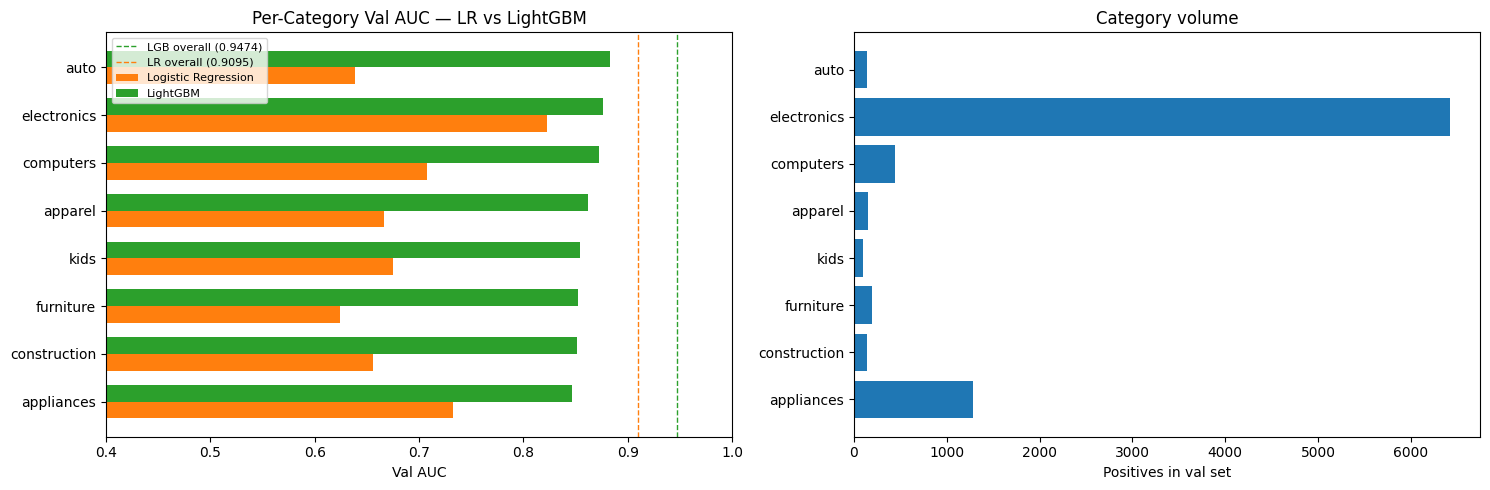

    category  n_pos  pos_rate  LR Val AUC  LGB Val AUC  delta
  appliances   1283    0.0368      0.7329       0.8465 0.1136
construction    141    0.0040      0.6558       0.8516 0.1958
   furniture    198    0.0057      0.6245       0.8519 0.2274
        kids     97    0.0028      0.6752       0.8547 0.1795
     apparel    154    0.0044      0.6668       0.8617 0.1948
   computers    445    0.0128      0.7080       0.8728 0.1648
 electronics   6425    0.1841      0.8229       0.8767 0.0537
        auto    138    0.0040      0.6382       0.8833 0.2451


In [12]:
# LR val predictions for comparison
lr_final = clone(sklearn_models['Logistic Regression'])
lr_final.fit(X_pool_sk, y_pool)
val_preds_lr = lr_final.predict_proba(X_val_sk)[:, 1]

cat_eval = []
for cat in KEPT_CATS:
    mask = val_df['category_l1'] == cat
    y_cat = y_val[mask.values]
    if len(np.unique(y_cat)) < 2:
        continue
    cat_eval.append({
        'category':    cat,
        'n_pos':       int(y_cat.sum()),
        'pos_rate':    y_cat.mean(),
        'LR Val AUC':  roc_auc_score(y_cat, val_preds_lr[mask.values]),
        'LGB Val AUC': roc_auc_score(y_cat, val_preds_lgb[mask.values]),
    })

cat_df = (
    pd.DataFrame(cat_eval)
    .assign(delta=lambda d: d['LGB Val AUC'] - d['LR Val AUC'])
    .sort_values('LGB Val AUC', ascending=True)
)

lr_overall_auc = results['Logistic Regression']['val_auc']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
y_pos = np.arange(len(cat_df))
w     = 0.35

axes[0].barh(y_pos - w/2, cat_df['LR Val AUC'],  w, color='tab:orange', label='Logistic Regression')
axes[0].barh(y_pos + w/2, cat_df['LGB Val AUC'], w, color='tab:green',  label='LightGBM')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(cat_df['category'])
axes[0].axvline(val_auc_lgb,    color='tab:green',  linestyle='--', lw=1, label=f'LGB overall ({val_auc_lgb:.4f})')
axes[0].axvline(lr_overall_auc, color='tab:orange', linestyle='--', lw=1, label=f'LR overall ({lr_overall_auc:.4f})')
axes[0].set_xlabel('Val AUC')
axes[0].set_title('Per-Category Val AUC — LR vs LightGBM')
axes[0].set_xlim(0.4, 1.0)
axes[0].legend(fontsize=8, loc='upper left')

axes[1].barh(y_pos, cat_df['n_pos'], color='tab:blue')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(cat_df['category'])
axes[1].set_xlabel('Positives in val set')
axes[1].set_title('Category volume')

plt.tight_layout()
plt.show()

print(cat_df.to_string(index=False))

### 7.2 Top-K Recall Curve

What percentage of actual buyers do we capture targeting the top X% of users? The diagonal is random selection, curves above it show the model's lift.

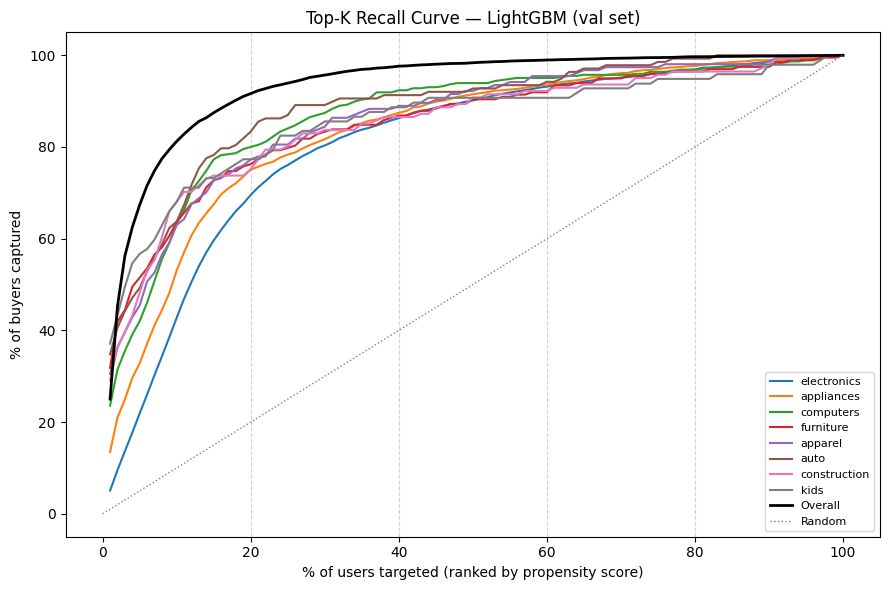

Buyers captured when targeting top 20% of users per category:
  electronics     69.5%
  appliances      75.1%
  computers       80.0%
  furniture       76.3%
  apparel         77.3%
  auto            83.3%
  construction    75.2%
  kids            77.3%


In [13]:
def top_k_recall(y_true, y_score, fracs):
    order    = np.argsort(y_score)[::-1]
    y_sorted = np.asarray(y_true)[order]
    total    = y_sorted.sum()
    if total == 0:
        return np.zeros(len(fracs))
    return np.array([y_sorted[:max(1, int(len(y_sorted) * f))].sum() / total for f in fracs])

fracs = np.linspace(0.01, 1.0, 100)

fig, ax = plt.subplots(figsize=(9, 6))
for cat in KEPT_CATS:
    mask = (val_df['category_l1'] == cat).values
    recall = top_k_recall(y_val[mask], val_preds_lgb[mask], fracs)
    ax.plot(fracs * 100, recall * 100, label=cat)

overall_recall = top_k_recall(y_val, val_preds_lgb, fracs)
ax.plot(fracs * 100, overall_recall * 100, 'k-', linewidth=2, label='Overall')
ax.plot([0, 100], [0, 100], 'gray', linestyle=':', linewidth=1, label='Random')

for x in [20, 40, 60, 80]:
    ax.axvline(x, color='lightgray', linestyle='--', linewidth=0.8, zorder=0)

ax.set_xlabel('% of users targeted (ranked by propensity score)')
ax.set_ylabel('% of buyers captured')
ax.set_title('Top-K Recall Curve — LightGBM (val set)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

print('Buyers captured when targeting top 20% of users per category:')
for cat in KEPT_CATS:
    mask   = (val_df['category_l1'] == cat).values
    recall = top_k_recall(y_val[mask], val_preds_lgb[mask], fracs)
    idx    = np.searchsorted(fracs, 0.20)
    print(f'  {cat:<15} {recall[idx]*100:.1f}%')

Targeting the top 20% of users captures 70-85% of actual buyers across all categories, a 3.5-4x lift over random selection.

### 7.3 Feature Importance

Split importance counts how often a feature is used for a tree split, averaged across CV folds. It measures usage frequency, not effect magnitude, so a feature that appears in many shallow splits can rank high without having a large per-prediction impact.

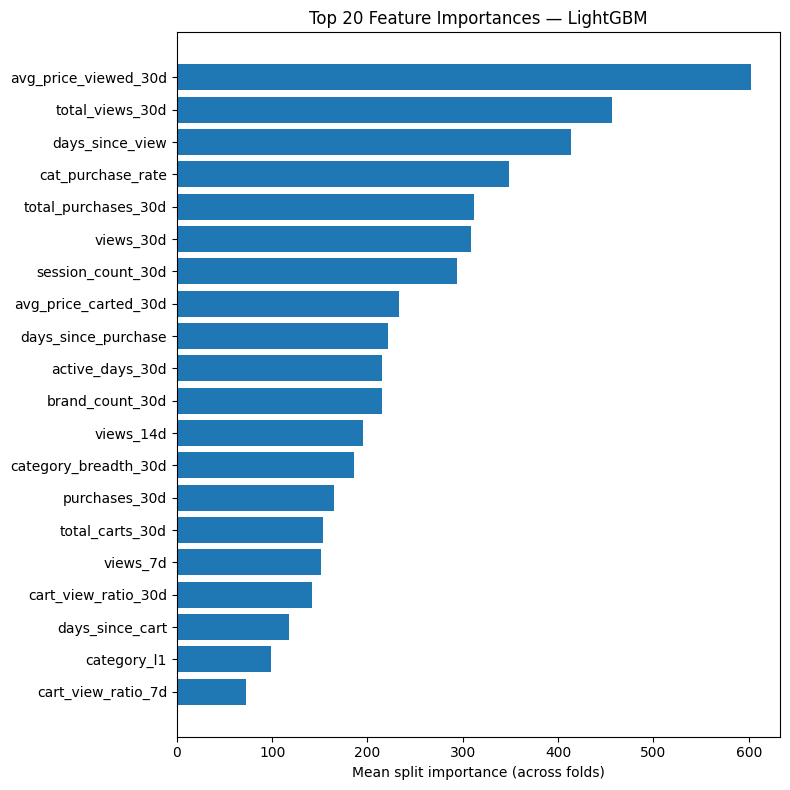

Top 10 features:
             feature  importance
avg_price_viewed_30d    602.6000
     total_views_30d    456.8000
     days_since_view    413.6000
   cat_purchase_rate    348.4000
 total_purchases_30d    311.4000
           views_30d    308.4000
   session_count_30d    294.4000
avg_price_carted_30d    232.6000
 days_since_purchase    221.8000
     active_days_30d    215.4000


In [14]:
imp_df = (
    pd.DataFrame({'feature': feature_cols, 'importance': feat_importances})
    .sort_values('importance', ascending=False)
)

top20 = imp_df.head(20).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top20['feature'], top20['importance'], color='tab:blue')
ax.set_xlabel('Mean split importance (across folds)')
ax.set_title('Top 20 Feature Importances — LightGBM')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(imp_df.head(10).to_string(index=False))

### 7.4 Cold-Start Users

These are users with no October activity, the model falls back on category base rates. I'll check how prevalent they are and whether the model performance degrades for this group.

In [15]:
# Cold-start users (total_views_30d == 0 after null fill)
cold_user_ids = (
    val_df.groupby('user_id')['total_views_30d']
    .first().fillna(0).eq(0)
    .pipe(lambda s: set(s[s].index))
)
cold_mask_cs = val_df['user_id'].isin(cold_user_ids).values
warm_mask_cs = ~cold_mask_cs

n_cold_users = len(cold_user_ids)
n_val_users  = val_df['user_id'].nunique()
print(f'Val set — cold-start users: {n_cold_users:,} ({n_cold_users / n_val_users:.1%})')
print(f'Val set — warm users:       {n_val_users - n_cold_users:,} ({(n_val_users - n_cold_users) / n_val_users:.1%})')

warm_auc = roc_auc_score(y_val[warm_mask_cs], val_preds_lgb[warm_mask_cs])
print(f'\nVal AUC  — warm: {warm_auc:.4f}')

cold_positives = int(y_val[cold_mask_cs].sum())
if cold_positives >= 2 and len(np.unique(y_val[cold_mask_cs])) > 1:
    cold_auc = roc_auc_score(y_val[cold_mask_cs], val_preds_lgb[cold_mask_cs])
    print(f'Val AUC  — cold: {cold_auc:.4f}  ({cold_positives} positives)')
else:
    print(f'Val AUC  — cold: n/a  ({cold_positives} positives — too few for AUC)')

cat_base_rate = train_pool['label'].mean()
print(f'\nMean predicted prob — cold: {val_preds_lgb[cold_mask_cs].mean():.4f}  '
      f'warm: {val_preds_lgb[warm_mask_cs].mean():.4f}')
print(f'Overall val positive rate: {val_pos_rate:.4f}  |  train pool positive rate: {cat_base_rate:.4f}')

Val set — cold-start users: 2,856 (8.2%)
Val set — warm users:       32,036 (91.8%)

Val AUC  — warm: 0.9406
Val AUC  — cold: 0.9256  (2917 positives)

Mean predicted prob — cold: 0.1276  warm: 0.0234
Overall val positive rate: 0.0318  |  train pool positive rate: 0.0323


#### Interpretation

Cold-start users are 8.2% of val users. Their positive rate is ~12.8% (2,917 positives across 2,856 x 8 scaffold rows), roughly 4 times the overall val rate of 3.18%. The model's mean predicted probability of 0.1277 matches this actual rate almost exactly, so it is well-calibrated for this group. The AUC is slightly below warm users (0.9256 vs 0.9406), meaning the model ranks this group reliably.

In `train_pool`, non-purchasers were sampled from Oct-active users, which means training examples with all zero features are purchasers. The model has never seen a zero-feature negative during training. Thus the model learns to associate absent features with high propensity. This is accurate for the current dataset but can be misleading in production; a completely new user would receive a ~12% prediction rather than ~the 3% base rate. This is a behavior-dataset limitation. In a live system, cold-start users would need to be scored separately.

## 8. Calibration

Propensity scores need to reflect true probabilities rather than just rankings in order to support expected-value calculations (for instance, expected revenue = propensity x average order value). Isotonic regression is one way to map raw lightgbm scores to observed probabilities. In this section I'll evaluate whether it actually improves the raw lightgbm scores.

I'll split the val set into two halves of user sets to evaluate calibration:

- val_calib: the isotonic calibrator is fitted here
- val_eval: evaluation only, neither the base model nor the calibrator has seen these users

The three-panel diagram shows:

1. raw model on val_eval
2. calibrated model on val_calib - this is in-sample, guaranteed to look perfect, included for basic check and has zero diagnostic value
3. calibrated model on val_eval - comparing this with panel 1 is what matters for checking whether calibration improves model reliability on unseen data

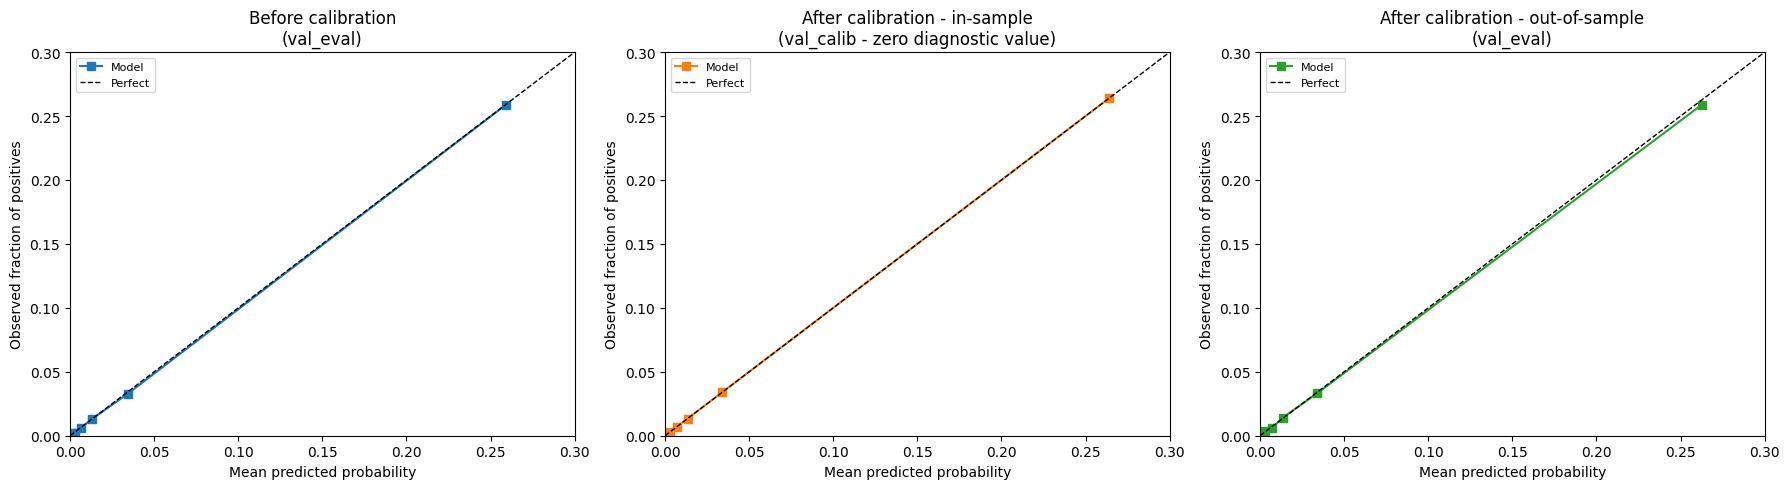

val_eval — LogLoss  before: 0.0715  |  after: 0.0723
val_eval — mean prob before: 0.0319  |  after: 0.0320  (true rate: 0.0315)


In [16]:
# Split val users into calibration and evaluation halves
val_users_arr  = val_df['user_id'].unique()
rng_cal        = np.random.default_rng(SEED)
calib_user_ids = set(rng_cal.choice(val_users_arr, size=len(val_users_arr) // 2, replace=False))

calib_mask    = val_df['user_id'].isin(calib_user_ids).values
eval_mask_cal = ~calib_mask

calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(val_preds_lgb[calib_mask], y_val[calib_mask])

val_calib_cal = calibrator.predict(val_preds_lgb[calib_mask])
val_eval_cal  = calibrator.predict(val_preds_lgb[eval_mask_cal])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
panels = [
    (axes[0], val_preds_lgb[eval_mask_cal], y_val[eval_mask_cal], 'tab:blue',   'Before calibration\n(val_eval)'),
    (axes[1], val_calib_cal, y_val[calib_mask], 'tab:orange', 'After calibration - in-sample\n(val_calib - zero diagnostic value)'),
    (axes[2], val_eval_cal, y_val[eval_mask_cal], 'tab:green', 'After calibration - out-of-sample\n(val_eval)'),
]

for ax, preds, y_true, color, title in panels:
    frac_pos, mean_pred = calibration_curve(y_true, preds, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 's-', color=color, label='Model')
    ax.plot([0, 0.3], [0, 0.3], 'k--', lw=1, label='Perfect')
    ax.set_xlim(0, 0.3)
    ax.set_ylim(0, 0.3)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Observed fraction of positives')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'val_eval — LogLoss  before: {log_loss(y_val[eval_mask_cal], val_preds_lgb[eval_mask_cal]):.4f}  '
      f'|  after: {log_loss(y_val[eval_mask_cal], val_eval_cal):.4f}')
print(f'val_eval — mean prob before: {val_preds_lgb[eval_mask_cal].mean():.4f}  '
      f'|  after: {val_eval_cal.mean():.4f}  (true rate: {y_val[eval_mask_cal].mean():.4f})')

#### Interpretation

Our model is already quite well-calibrated on the val set (val mean prob: 0.0320, pos rate: 0.0318). Isotonic regression slightly worsened log loss on `val_eval` indicating calibration introduced noise rather than correcting. Therefore I'll use raw lightgbm scores for final test predictions.

## 9. Negative Sampling Experiment

In order to observe how training data affects the model, I'll compare two scaffolds in this section:

- `train_pool`: All (user, category)-pairs, purchasers and non-purchasers (~3.2% positive rate). The model must learn to distinguish buyers from non-buyers, this matches the deployment scenario of scoring all users.
- `train_purchaser`: Only users who made at least one purchase in Nov 1–5 (~13% positive rate). This is case-control sampling: Class imbalance is much less severe, and training is conditioned on a user having purchased somewhere. The model is directed towards "Given a user bought something, which category did they buy in?"

Both are evaluated on the same val set, which contains non-purchasers, similar to what the model would see in real-life.

I'll include logistic regression alongside lightgbm; if the two models degrade asymmetrically under `train_purchaser`, that shows us that the performance difference is a training data problem rather than a model capacity one.

In [17]:
purchaser_ids   = set(train_pool.loc[train_pool['label'] == 1, 'user_id'].unique())
train_purchaser = train_pool[train_pool['user_id'].isin(purchaser_ids)].copy()

print(f'{"Scaffold":<20} {"rows":>10}  {"positive rate":>14}')
print('-' * 48)
print(f'{"train_pool":<20} {len(train_pool):>10,}  {train_pool["label"].mean():>14.2%}')
print(f'{"train_purchaser":<20} {len(train_purchaser):>10,}  {train_purchaser["label"].mean():>14.2%}')
print(f'{"val_df (anchor)":<20} {len(val_df):>10,}  {val_pos_rate:>14.2%}')

Scaffold                   rows   positive rate
------------------------------------------------
train_pool            1,116,576           3.23%
train_purchaser         278,152          12.96%
val_df (anchor)         279,136           3.18%


In [18]:
EXP_LGB_PARAMS = dict(n_estimators=200, random_state=SEED, verbose=-1, n_jobs=-1)
EXP_LR_PIPELINE = Pipeline([
    ('prep', lr_prep),
    ('clf', LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)),
])

exp_results = []
for train_df, label in [(train_pool, 'train_pool'), (train_purchaser, 'train_purchaser')]:
    X_tr     = train_df[feature_cols].copy()
    y_tr     = train_df['label'].values

    X_tr_lgb = X_tr.copy()
    for col in cat_cols:
        X_tr_lgb[col] = X_tr_lgb[col].astype('category')
    lgb_m = lgb.LGBMClassifier(**EXP_LGB_PARAMS)
    lgb_m.fit(X_tr_lgb, y_tr)
    preds_lgb = lgb_m.predict_proba(X_val_lgb)[:, 1]
    exp_results.append({
        'model': 'LightGBM', 'scaffold': label,
        'val_auc':       roc_auc_score(y_val, preds_lgb),
        'val_logloss':   log_loss(y_val, preds_lgb),
        'val_mean_prob': preds_lgb.mean(),
    })

    lr_m = copy.deepcopy(EXP_LR_PIPELINE)
    lr_m.fit(X_tr, y_tr)
    preds_lr = lr_m.predict_proba(X_val_sk)[:, 1]
    exp_results.append({
        'model': 'LR', 'scaffold': label,
        'val_auc':       roc_auc_score(y_val, preds_lr),
        'val_logloss':   log_loss(y_val, preds_lr),
        'val_mean_prob': preds_lr.mean(),
    })

exp_df = pd.DataFrame(exp_results)
print(f'Val positive rate (ground truth): {val_pos_rate:.4f}\n')
print(exp_df.to_string(index=False))

Val positive rate (ground truth): 0.0318

   model        scaffold  val_auc  val_logloss  val_mean_prob
LightGBM      train_pool   0.9470       0.0725         0.0319
      LR      train_pool   0.9095       0.0877         0.0323
LightGBM train_purchaser   0.9097       0.2075         0.1256
      LR train_purchaser   0.9065       0.2135         0.1233


### Interpretation

Both `train_purchaser`-trained models show significant log-loss increase and the mean prob jumps from ~0.03 to ~0.12 (close to pos rate of `train_purchaser`) when compared with `train_pool` training. The models become overconfident because they have never seen the soft-negative cases during training, they cannot distinguish a low-propensity non-purchaser from a purchaser who has not bought in this category.

The AUC asymmetry confirms this is a training data problem, not model capacity since lightgbm AUC drop is more severe than logistic regression by a notable margin. A tree precisely memorizes the decision boundary whereas a linear boundary is structurally better suited to generalize to unseen non-purchaser cases. When `train_pool`-trained lightgbm performs better than lr, yet can barely match lr on `train_purchaser`, the issue is the training data.

Case-control sampling such as this one can be useful when positives are very rare and we need to balance the training set, but in our case using the full scaffold is the correct choice; the model must score all users, not just known purchasers.

## 10. Final Model & Test Predictions

The final model is retrained on the full labeled dataset (`train_pool` + `val_df`) using `mean_iters`.

In [19]:
X_full_lgb = train[feature_cols].copy()
y_full     = train['label']
for col in cat_cols:
    X_full_lgb[col] = X_full_lgb[col].astype('category')

X_test_lgb = test[feature_cols].copy()
for col in cat_cols:
    X_test_lgb[col] = X_test_lgb[col].astype('category')

full_params = {**lgb_params, 'n_estimators': mean_iters}
full_model  = lgb.LGBMClassifier(**full_params)
full_model.fit(X_full_lgb, y_full)

test_preds = full_model.predict_proba(X_test_lgb)[:, 1]

print(f'Final model: {mean_iters} trees')
print(f'Test predictions — min: {test_preds.min():.4f}  median: {np.median(test_preds):.4f}  max: {test_preds.max():.4f}')
print(f'Mean predicted probability: {test_preds.mean():.4f}  (train positive rate: {y_full.mean():.4f})')

Final model: 159 trees
Test predictions — min: 0.0003  median: 0.0024  max: 0.9880
Mean predicted probability: 0.0323  (train positive rate: 0.0322)


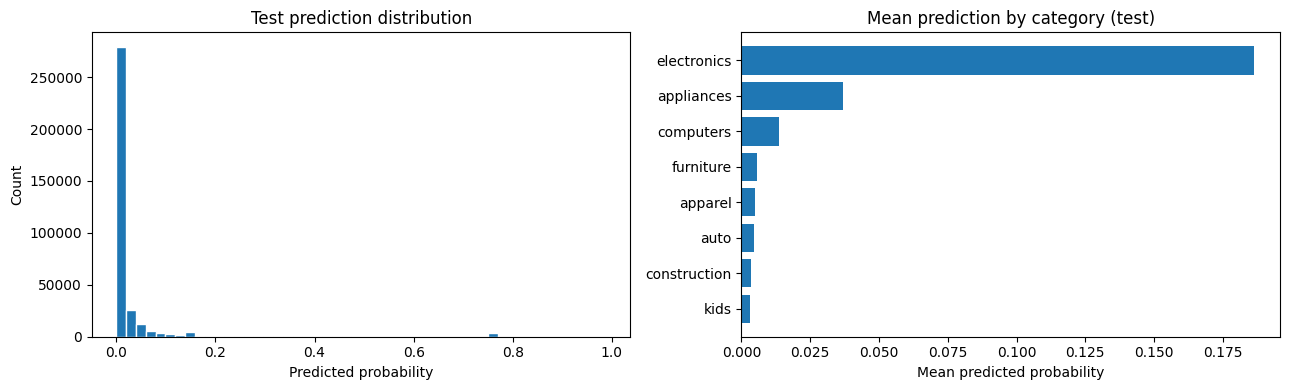

Output shape: (348928, 3)


,user_id,category_l1,propensity_score
28626,512437914,apparel,0.7653
71954,536711774,apparel,0.7068
204698,547066883,apparel,0.6739
61690,559930324,apparel,0.6712
38034,532509330,apparel,0.6674
65018,544375839,apparel,0.6515
38674,514068500,apparel,0.6477
66586,559499344,apparel,0.6466
48690,512393077,apparel,0.6444
80490,560914255,apparel,0.6424


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(test_preds, bins=50, edgecolor='white', color='tab:blue')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Test prediction distribution')

cat_means = (
    pd.DataFrame({'category': test['category_l1'], 'prob': test_preds})
    .groupby('category')['prob'].mean()
    .sort_values()
)
axes[1].barh(cat_means.index, cat_means.values, color='tab:blue')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_title('Mean prediction by category (test)')

plt.tight_layout()
plt.show()

output = test[['user_id', 'category_l1']].copy()
output['propensity_score'] = test_preds
output = output.sort_values(['category_l1', 'propensity_score'], ascending=[True, False])
print(f'Output shape: {output.shape}')
output.head(10)

In [21]:
output.to_parquet(FEATURES_DIR / 'test_predictions.parquet', index=False)
print('Saved: test_predictions.parquet')

Saved: test_predictions.parquet


## 11. Conclusion

We have built a calibrated lightgbm purchase propensity model for (user, category)-pairs. Output values are propensity scores closely aligned with observed purchase rates, suitable for expected value calculations (for instance, expected revenue = propensity x average order value) or direct use as input to targeting logic (for instance, ranking users within a category for targeting).

### Key findings

- Naive baseline of category purchase rates already gives a solid start at 0.87 val AUC, reflecting the strong category-based signal in purchase behavior. Moving to logistic regression adds user-level signal, and lightgbm captures non-linear interactions and gives the best overall performance.

| Model | OOF AUC | Val AUC | Val LogLoss |
|---|---|---|---|
| LightGBM | 0.9455 | 0.9474 | 0.0723 |
| Logistic Regression | 0.9086 | 0.9095 | 0.0877 |
| Naive Baseline | 0.8699 | 0.8705 | 0.1048 |

- LGB is robust to hyperparameter changes; AUC change across 20 random search trials was under 0.001. The dataset's signal is strong enough that parameter sensitivity is low.

- Price features lead in feature importance; `avg_price_viewed_30d` is the top feature by a notable margin, with `avg_price_carted_30d` also in the top 10. These features capture the user's price segment, which is predictive of category-level purchase propensity. Cross-category activity (`total_views_30d`, `total_purchases_30d`, `session_count_30d`) ranks above category-specific counts, suggesting that overall engagement level generalizes well across categories. One would guess cart activity points to purchase intent, but surprisingly, category-specific cart counts (`carts_30d`, `carts_7d`) are among the weakest features.

- The model is already well-calibrated in expectation (val mean prob 0.0320, val pos rate 0.0318). Applying isotonic regression slightly worsened log loss on the held-out evaluation half of val set (0.0715 → 0.0723) indicating the calibrator introduced noise rather than correction. Therefore raw lightgbm scores are used for final predictions.

- Experimenting with a purchaser-only scaffold shows that lightgbm needs the full population scaffold to generalise; its AUC drops by 0.037 while logistic regression drops only 0.003, confirming the gap is a training data problem, not model capacity.

### Limitations

This propensity model identifies users most likely to purchase, but doesn't say anything about causality. For estimating the causal effect of targeting on purchase probability, we need an uplift model including randomized experiments. The assumption that high-propensity users have higher expected return per contact may hold in practice but this propensity model cannot confirm whether the targeting itself caused the purchase.